   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

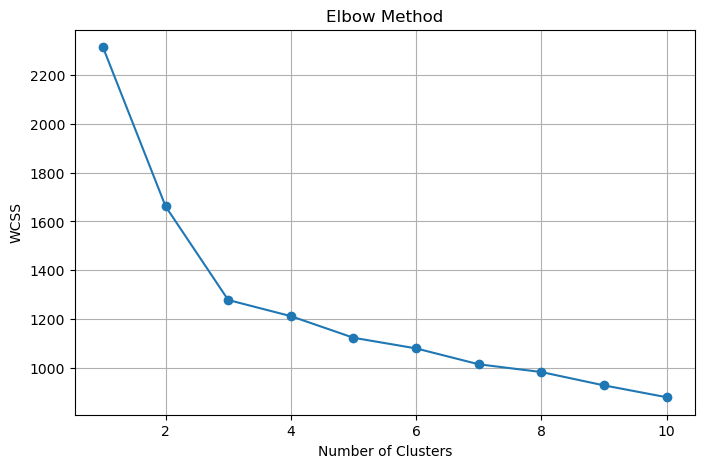

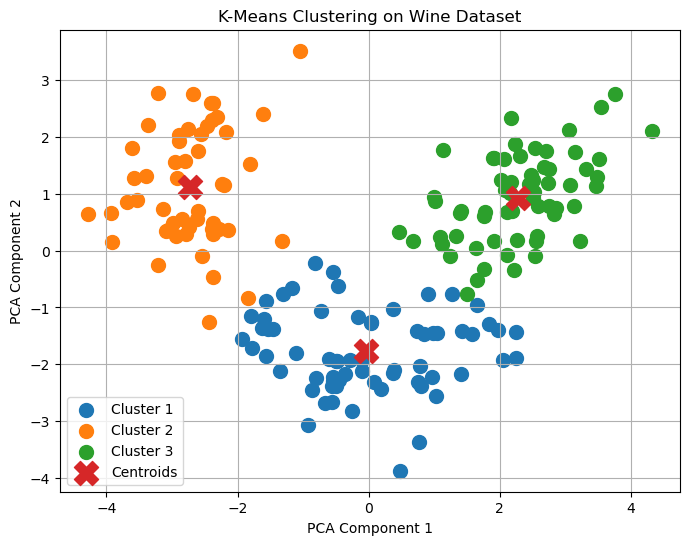

In [5]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
wine = load_wine()

X = wine.data
y = wine.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=wine.feature_names)

print(df.head())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find WCSS values
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# Train KMeans Model
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

y_kmeans = kmeans.fit_predict(X_scaled)

# Reduce dimensions using PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Plot Clusters
plt.figure(figsize=(8,6))

plt.scatter(X_pca[y_kmeans == 0, 0],
            X_pca[y_kmeans == 0, 1],
            s=100,
            label='Cluster 1')

plt.scatter(X_pca[y_kmeans == 1, 0],
            X_pca[y_kmeans == 1, 1],
            s=100,
            label='Cluster 2')

plt.scatter(X_pca[y_kmeans == 2, 0],
            X_pca[y_kmeans == 2, 1],
            s=100,
            label='Cluster 3')

# Plot Centroids
centroids = pca.transform(kmeans.cluster_centers_)

plt.scatter(centroids[:,0],
            centroids[:,1],
            s=300,
            marker='X',
            label='Centroids')

plt.title("K-Means Clustering on Wine Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)

plt.show()